# Hybrid and Explainable Machine Learning for LAI Polymer Drug Release

This notebook continues the Orange homework into a full Python project.

**Main project idea:**  
Move from basic point-wise model comparison toward **profile-aware validation**, **zero-shot vs few-shot prediction**, **full release profile simulation**, **SHAP interpretation**, **hybrid kinetic ML**, and **physically plausible release curves**.

Use this notebook as both:
1. the reproducible technical workflow, and  
2. a source of short comments/paragraphs that can be copied into the paper.

> Paper comment: The initial Orange analysis is treated as an exploratory baseline. The final project is continued in Python because Python allows grouped validation, full-profile prediction, SHAP explainability, kinetic model fitting, and physically constrained post-processing.

## 1. Install packages

Run this cell in Colab.  
If you run locally and already have the packages installed, you can skip it.

In [33]:
import shutil, sys

if shutil.which("uv"):
    !uv pip install --python "{sys.executable}" -q lightgbm xgboost shap scipy scikit-learn pandas matplotlib openpyxl
else:
    %pip install -q lightgbm xgboost shap scipy scikit-learn pandas matplotlib openpyxl

## 2. Imports and general settings

In [34]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.optimize import curve_fit
from scipy.stats import spearmanr

from sklearn.base import clone
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GroupKFold, KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import Ridge
from sklearn.cross_decomposition import PLSRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.multioutput import MultiOutputRegressor

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

OUTPUT_DIR = "lai_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 150)

## 3. Load the dataset

Upload `Dataset_17_feat.csv` to Colab files, or keep it in the same folder as this notebook.

Expected columns:
- `Experimental_index`
- `DP_Group`
- 17 input descriptors
- `Release` target

In [35]:
DATA_PATH = "Dataset_17_feat.csv"

# Colab helper: if the file is not present, ask the user to upload it.
# if not os.path.exists(DATA_PATH):
#     try:
#         from google.colab import files
#         print("Dataset_17_feat.csv not found. Please upload it now.")
#         uploaded = files.upload()
#         if "Dataset_17_feat.csv" in uploaded:
#             DATA_PATH = "Dataset_17_feat.csv"
#     except Exception:
#         pass

df = pd.read_csv(DATA_PATH)

# Sort by profile and time. This is useful for profile plotting later.
df = df.sort_values(["Experimental_index", "Time"]).reset_index(drop=True)

print("Dataset shape:", df.shape)
display(df.head())
display(df.dtypes)

Dataset shape: (3783, 20)


,Experimental_index,DP_Group,LA/GA,Polymer_MW,CL Ratio,Drug_Tm,Drug_Pka,Initial D/M ratio,DLC,SA-V,SE,Drug_Mw,Drug_TPSA,Drug_NHA,Drug_LogP,Time,T=0.25,T=0.5,T=1.0,Release
0,1,DEX-PEA,0.0,49000.0,0.0,262.0,12.42,0.2,0.15,422.54,0.0,392.47,94.83,6.0,1.9,0.00,0.04,0.05,0.09,0.00
1,1,DEX-PEA,0.0,49000.0,0.0,262.0,12.42,0.2,0.15,422.54,0.0,392.47,94.83,6.0,1.9,0.17,0.04,0.05,0.09,0.03
2,1,DEX-PEA,0.0,49000.0,0.0,262.0,12.42,0.2,0.15,422.54,0.0,392.47,94.83,6.0,1.9,1.03,0.04,0.05,0.09,0.12
3,1,DEX-PEA,0.0,49000.0,0.0,262.0,12.42,0.2,0.15,422.54,0.0,392.47,94.83,6.0,1.9,3.26,0.04,0.05,0.09,0.20
4,1,DEX-PEA,0.0,49000.0,0.0,262.0,12.42,0.2,0.15,422.54,0.0,392.47,94.83,6.0,1.9,7.04,0.04,0.05,0.09,0.28


Experimental_index      int64
DP_Group               object
LA/GA                 float64
Polymer_MW            float64
CL Ratio              float64
Drug_Tm               float64
Drug_Pka              float64
Initial D/M ratio     float64
DLC                   float64
SA-V                  float64
SE                    float64
Drug_Mw               float64
Drug_TPSA             float64
Drug_NHA              float64
Drug_LogP             float64
Time                  float64
T=0.25                float64
T=0.5                 float64
T=1.0                 float64
Release               float64
dtype: object

### Paper comment: Dataset description

You can adapt this paragraph:

> The dataset contains individual fractional drug release measurements from multiple long-acting injectable polymer formulations. Each formulation profile is identified by `Experimental_index`, while `DP_Group` denotes the drug-polymer group. The target variable is `Release`, representing fractional drug release at a given time point. Most formulation and drug descriptors remain constant within one release profile, while `Time` changes across the profile.

## 4. Define target, identifiers, and feature sets

We create two versions of the model:

**Zero-shot prediction**  
Uses only formulation/drug descriptors available before the release experiment.

**Few-shot prediction**  
Uses formulation/drug descriptors plus early release values:
- `T=0.25`
- `T=0.5`
- `T=1.0`

These early values act as proxies for initial burst release.

In [9]:
ID_COLS = ["Experimental_index", "DP_Group"]
TARGET = "Release"
EARLY_FEATURES = ["T=0.25", "T=0.5", "T=1.0"]

# All numeric input columns except identifiers and target.
ALL_FEATURES = [c for c in df.columns if c not in ID_COLS + [TARGET]]

# Zero-shot: no early measured release values.
ZERO_SHOT_FEATURES = [c for c in ALL_FEATURES if c not in EARLY_FEATURES]

# Few-shot: includes early measured release values.
FEW_SHOT_FEATURES = ALL_FEATURES.copy()

# Main grouping variable for profile-aware validation.
# This prevents rows from the same release profile appearing in both train and test.
GROUP_COL = "Experimental_index"
groups = df[GROUP_COL]

print("All features:", ALL_FEATURES)
print("\nZero-shot features:", ZERO_SHOT_FEATURES)
print("\nFew-shot features:", FEW_SHOT_FEATURES)
print("\nNumber of unique release profiles:", df["Experimental_index"].nunique())
print("Number of unique drug-polymer groups:", df["DP_Group"].nunique())

All features: ['LA/GA', 'Polymer_MW', 'CL Ratio', 'Drug_Tm', 'Drug_Pka', 'Initial D/M ratio', 'DLC', 'SA-V', 'SE', 'Drug_Mw', 'Drug_TPSA', 'Drug_NHA', 'Drug_LogP', 'Time', 'T=0.25', 'T=0.5', 'T=1.0']

Zero-shot features: ['LA/GA', 'Polymer_MW', 'CL Ratio', 'Drug_Tm', 'Drug_Pka', 'Initial D/M ratio', 'DLC', 'SA-V', 'SE', 'Drug_Mw', 'Drug_TPSA', 'Drug_NHA', 'Drug_LogP', 'Time']

Few-shot features: ['LA/GA', 'Polymer_MW', 'CL Ratio', 'Drug_Tm', 'Drug_Pka', 'Initial D/M ratio', 'DLC', 'SA-V', 'SE', 'Drug_Mw', 'Drug_TPSA', 'Drug_NHA', 'Drug_LogP', 'Time', 'T=0.25', 'T=0.5', 'T=1.0']

Number of unique release profiles: 181
Number of unique drug-polymer groups: 34


### Paper comment: Zero-shot vs few-shot

> Two prediction scenarios were defined. The zero-shot model used only descriptors available before release testing, while the few-shot model also included the first early release measurements at 6 h, 12 h, and 24 h. This comparison evaluates whether a small amount of early experimental information improves prediction of the remaining release profile.

## 5. Basic EDA reproduced in Python

This section replaces the need to manually extract everything from Orange.

It checks:
- missing values
- summary statistics
- target distribution
- feature correlation

In [36]:
# Missing values
missing_table = df.isna().sum().to_frame("missing_count")
missing_table["missing_percent"] = 100 * missing_table["missing_count"] / len(df)
display(missing_table)

# Basic statistics
display(df.describe().T)

# Save summary table for the paper
df.describe().T.to_csv(os.path.join(OUTPUT_DIR, "summary_statistics.csv"))
missing_table.to_csv(os.path.join(OUTPUT_DIR, "missing_values.csv"))

,missing_count,missing_percent
Experimental_index,0,0.0
DP_Group,0,0.0
LA/GA,0,0.0
Polymer_MW,0,0.0
CL Ratio,0,0.0
Drug_Tm,0,0.0
Drug_Pka,0,0.0
Initial D/M ratio,0,0.0
DLC,0,0.0
SA-V,0,0.0


,count,mean,std,min,25%,50%,75%,max
Experimental_index,3783.0,109.012688,52.938740,1.00,66.000,124.00,154.00,181.00
LA/GA,3783.0,0.804766,1.014624,0.00,0.000,1.00,1.00,3.00
Polymer_MW,3783.0,35788.243458,24367.696754,8300.00,15000.000,32000.00,44000.00,108000.00
CL Ratio,3783.0,0.062950,0.067476,0.00,0.000,0.04,0.15,0.18
Drug_Tm,3783.0,212.501586,66.170200,66.00,206.000,216.50,262.00,312.50
Drug_Pka,3783.0,10.706394,2.532575,4.40,10.360,10.36,11.75,19.69
Initial D/M ratio,3783.0,0.705757,0.626395,0.01,0.115,0.83,1.00,2.50
DLC,3783.0,0.185916,0.129409,0.00,0.060,0.18,0.31,0.62
SA-V,3783.0,696.890563,2298.216607,2.48,2.890,65.93,155.56,22018.35
SE,3783.0,0.292556,0.261045,0.00,0.000,0.50,0.50,1.00


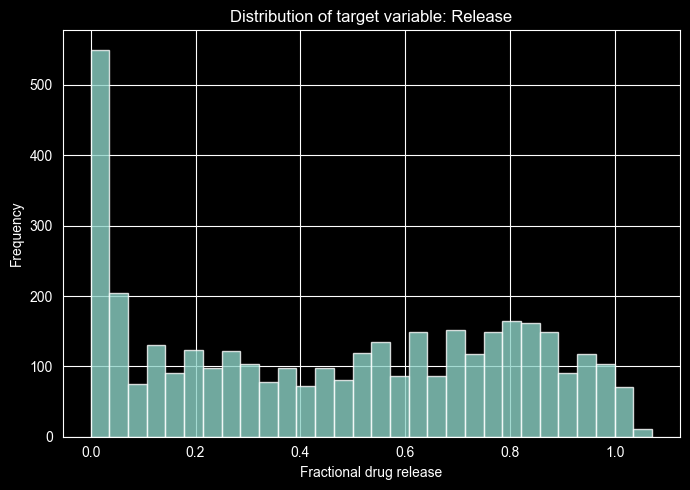

In [11]:
plt.figure(figsize=(7, 5))
plt.hist(df[TARGET], bins=30, alpha=0.8)
plt.xlabel("Fractional drug release")
plt.ylabel("Frequency")
plt.title("Distribution of target variable: Release")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "target_distribution.png"), dpi=300)
plt.show()

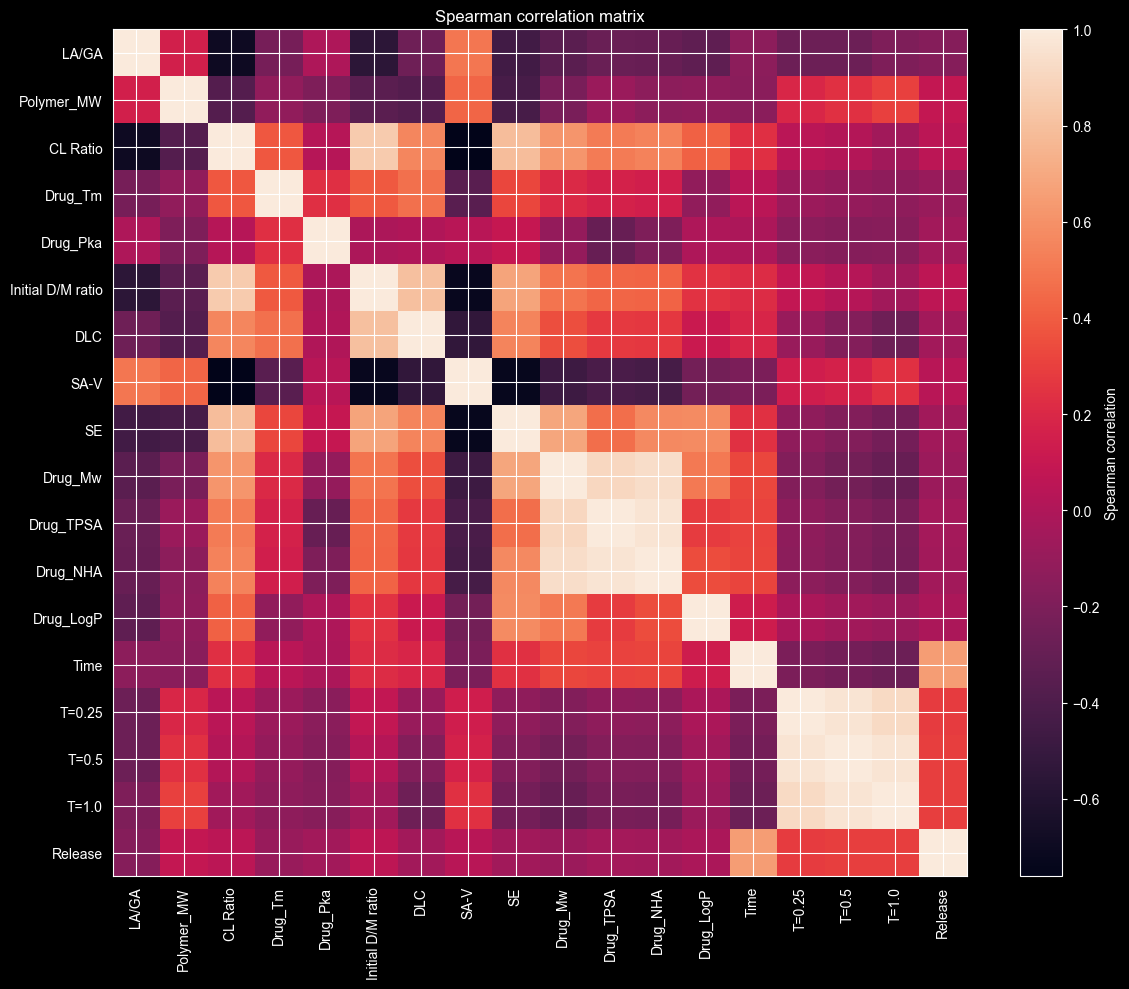

In [12]:
# Correlation matrix for numeric features and target
corr_cols = ALL_FEATURES + [TARGET]
corr = df[corr_cols].corr(method="spearman")

plt.figure(figsize=(12, 10))
plt.imshow(corr, aspect="auto")
plt.xticks(range(len(corr_cols)), corr_cols, rotation=90)
plt.yticks(range(len(corr_cols)), corr_cols)
plt.colorbar(label="Spearman correlation")
plt.title("Spearman correlation matrix")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "spearman_correlation_matrix.png"), dpi=300)
plt.show()

# Save correlation matrix
corr.to_csv(os.path.join(OUTPUT_DIR, "spearman_correlation_matrix.csv"))

### Paper comment: EDA

> Exploratory analysis was repeated in Python to make the workflow reproducible. Missing values, descriptive statistics, target distribution, and correlation structure were examined before model training. This step is important because several descriptors describe related physicochemical properties, so redundancy and multicollinearity are expected.

## 6. Optional: VIF analysis for linear baseline

VIF is mainly useful for linear models.  
Tree-based models can handle correlated features better, but VIF is still useful as a connection to the Orange homework.

In [37]:
# Optional VIF function.
# statsmodels may not be installed in every environment, so install if needed.
try:
    from statsmodels.stats.outliers_influence import variance_inflation_factor
except ImportError:
    import shutil, sys
    if shutil.which("uv"):
        !uv pip install --python "{sys.executable}" -q statsmodels
    else:
        %pip install -q statsmodels
    from statsmodels.stats.outliers_influence import variance_inflation_factor

def calculate_vif(dataframe, features):
    X_vif = dataframe[features].copy()
    X_vif = X_vif.replace([np.inf, -np.inf], np.nan).dropna()

    # VIF requires numeric features and no constant duplicate problems.
    X_values = X_vif.values

    rows = []
    for i, col in enumerate(features):
        try:
            vif_value = variance_inflation_factor(X_values, i)
        except Exception:
            vif_value = np.nan
        rows.append({"Feature": col, "VIF": vif_value})

    return pd.DataFrame(rows).sort_values("VIF", ascending=False)

vif_table = calculate_vif(df, ALL_FEATURES)
display(vif_table)

vif_table.to_csv(os.path.join(OUTPUT_DIR, "vif_all_features.csv"), index=False)

,Feature,VIF
9,Drug_Mw,565.959213
11,Drug_NHA,402.248273
10,Drug_TPSA,400.199306
15,T=0.5,111.838240
16,T=1.0,50.646403
14,T=0.25,39.919470
12,Drug_LogP,33.268305
4,Drug_Pka,18.536084
3,Drug_Tm,18.340037
5,Initial D/M ratio,12.827757


In [39]:
def iterative_vif_selection(dataframe, features, threshold=5.0):
    selected = features.copy()
    history = []

    while True:
        vif_table = calculate_vif(dataframe, selected)
        max_vif = vif_table["VIF"].max()

        if pd.isna(max_vif) or max_vif <= threshold:
            break

        remove_feature = vif_table.iloc[0]["Feature"]
        history.append({
            "removed_feature": remove_feature,
            "max_vif": max_vif,
            "remaining_features": len(selected) - 1
        })
        selected.remove(remove_feature)

    final_vif = calculate_vif(dataframe, selected)
    return selected, pd.DataFrame(history), final_vif

vif_selected_features, vif_history, final_vif = iterative_vif_selection(df, ALL_FEATURES, threshold=5.0)

print("Selected features after iterative VIF:")
print(vif_selected_features)

display(vif_history)
display(final_vif)

vif_history.to_csv(os.path.join(OUTPUT_DIR, "vif_elimination_history.csv"), index=False)
final_vif.to_csv(os.path.join(OUTPUT_DIR, "vif_selected_features.csv"), index=False)

Selected features after iterative VIF:
['LA/GA', 'Polymer_MW', 'DLC', 'SA-V', 'Drug_TPSA', 'Drug_LogP', 'Time', 'T=0.25']


,removed_feature,max_vif,remaining_features
0,Drug_Mw,565.959213,16
1,Drug_NHA,344.736909,15
2,T=0.5,94.424485,14
3,T=1.0,17.697707,13
4,Drug_Tm,15.364699,12
5,Initial D/M ratio,12.183919,11
6,Drug_Pka,8.446216,10
7,CL Ratio,6.946450,9
8,SE,5.063465,8


,Feature,VIF
4,Drug_TPSA,4.031936
2,DLC,3.702584
5,Drug_LogP,3.376416
1,Polymer_MW,3.329146
7,T=0.25,1.936235
6,Time,1.925993
0,LA/GA,1.770712
3,SA-V,1.607809


### Paper comment: VIF

> VIF analysis was used only to support the interpretation of linear models. After iterative elimination of highly collinear predictors, a reduced feature set can be used for Ridge/MLR-style baselines. However, the main predictive models in this project are tree-based because the Orange homework already suggested that the release process is not purely linear.

## 7. Profile-aware GroupKFold validation

This is one of the most important improvements over a basic homework approach.

A random row split is not appropriate here because one formulation appears at many time points.  
If points from the same release curve appear in both training and testing, the model can look artificially good.

So we use `GroupKFold` with `Experimental_index`.

In [40]:
def regression_metrics(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred)
    }

def evaluate_group_cv(model, X, y, groups, n_splits=5):
    '''
    Evaluates a regression model using GroupKFold.

    This prevents leakage between time points from the same release profile.
    '''
    gkf = GroupKFold(n_splits=n_splits)
    fold_rows = []
    oof_pred = np.zeros(len(y), dtype=float)
    oof_fold = np.zeros(len(y), dtype=int)

    for fold, (train_idx, test_idx) in enumerate(gkf.split(X, y, groups)):
        model_fold = clone(model)

        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        model_fold.fit(X_train, y_train)
        pred = np.ravel(model_fold.predict(X_test))

        oof_pred[test_idx] = pred
        oof_fold[test_idx] = fold

        metrics = regression_metrics(y_test, pred)
        metrics["fold"] = fold
        metrics["n_test_rows"] = len(test_idx)
        metrics["n_test_groups"] = groups.iloc[test_idx].nunique()
        fold_rows.append(metrics)

    fold_df = pd.DataFrame(fold_rows)
    summary = {
        "MAE_mean": fold_df["MAE"].mean(),
        "MAE_std": fold_df["MAE"].std(),
        "RMSE_mean": fold_df["RMSE"].mean(),
        "RMSE_std": fold_df["RMSE"].std(),
        "R2_mean": fold_df["R2"].mean(),
        "R2_std": fold_df["R2"].std()
    }

    oof_df = pd.DataFrame({
        "y_true": y.values,
        "y_pred": oof_pred,
        "fold": oof_fold,
        "Experimental_index": df["Experimental_index"].values,
        "DP_Group": df["DP_Group"].values,
        "Time": df["Time"].values
    })

    return fold_df, summary, oof_df

### Paper comment: Validation

> Model performance was evaluated with profile-aware GroupKFold cross-validation. The grouping variable was `Experimental_index`, which means all time points belonging to the same release profile were kept together either in training or testing. This gives a more realistic estimate of generalization to unseen release profiles.

## 8. Repeat and improve the Orange baseline in Python

Models:
- Ridge regression as a linear baseline
- PLS regression
- Random Forest
- Gradient Boosting
- XGBoost
- LightGBM

The goal is not only to repeat Orange, but to repeat it with correct profile-aware validation.

In [41]:
models = {
    "Ridge": make_pipeline(StandardScaler(), Ridge(alpha=1.0)),
    "PLS": make_pipeline(StandardScaler(), PLSRegression(n_components=5)),
    "Random Forest": RandomForestRegressor(
        n_estimators=400,
        random_state=RANDOM_STATE,
        min_samples_leaf=2,
        n_jobs=-1
    ),
    "Gradient Boosting": GradientBoostingRegressor(
        random_state=RANDOM_STATE
    ),
    "XGBoost": XGBRegressor(
        n_estimators=500,
        learning_rate=0.03,
        max_depth=3,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    "LightGBM": LGBMRegressor(
        n_estimators=500,
        learning_rate=0.03,
        num_leaves=31,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=RANDOM_STATE,
        verbose=-1
    )
}

X_all = df[ALL_FEATURES]
y = df[TARGET]

baseline_rows = []
baseline_oof = {}

for name, model in models.items():
    print(f"Evaluating: {name}")
    fold_df, summary, oof_df = evaluate_group_cv(model, X_all, y, groups, n_splits=5)
    row = {"model": name, **summary}
    baseline_rows.append(row)
    baseline_oof[name] = oof_df

baseline_results = pd.DataFrame(baseline_rows).sort_values("MAE_mean")
display(baseline_results)

baseline_results.to_csv(os.path.join(OUTPUT_DIR, "baseline_groupcv_results.csv"), index=False)

Evaluating: Ridge
Evaluating: PLS
Evaluating: Random Forest
Evaluating: Gradient Boosting
Evaluating: XGBoost
Evaluating: LightGBM


,model,MAE_mean,MAE_std,RMSE_mean,RMSE_std,R2_mean,R2_std
5,LightGBM,0.069756,0.011250,0.105538,0.020222,0.894590,0.034014
2,Random Forest,0.070500,0.012289,0.108738,0.020336,0.888036,0.035199
4,XGBoost,0.084936,0.009887,0.114394,0.012946,0.876470,0.030065
3,Gradient Boosting,0.088809,0.008905,0.119428,0.011881,0.865691,0.030134
0,Ridge,0.199776,0.011163,0.243758,0.011708,0.448411,0.033752
1,PLS,0.207204,0.007595,0.251367,0.008641,0.411738,0.055018


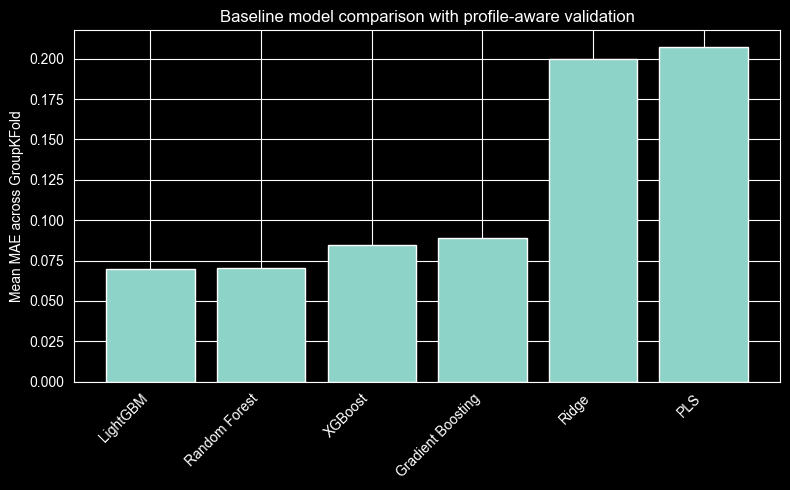

In [42]:
plt.figure(figsize=(8, 5))
plt.bar(baseline_results["model"], baseline_results["MAE_mean"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Mean MAE across GroupKFold")
plt.title("Baseline model comparison with profile-aware validation")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "baseline_model_comparison_mae.png"), dpi=300)
plt.show()

### Paper comment: Baseline model comparison

> The Orange baseline was repeated in Python using the same general model families but with grouped validation. Linear models served as interpretable baselines, while tree-based methods were used to capture non-linear relationships between formulation descriptors and release. The best-performing model from this comparison was selected for full-profile prediction and interpretation.

## 9. Zero-shot vs few-shot prediction

This is one of the strongest project parts.

- **Zero-shot:** no early release measurements.  
- **Few-shot:** includes `T=0.25`, `T=0.5`, `T=1.0`.

Use the same model architecture and compare performance.

In [43]:
zero_model = LGBMRegressor(
    n_estimators=700,
    learning_rate=0.025,
    num_leaves=31,
    min_child_samples=10,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=RANDOM_STATE,
    verbose=-1
)

few_model = clone(zero_model)

X_zero = df[ZERO_SHOT_FEATURES]
X_few = df[FEW_SHOT_FEATURES]

zero_fold_df, zero_summary, zero_oof = evaluate_group_cv(
    zero_model, X_zero, y, groups, n_splits=5
)

few_fold_df, few_summary, few_oof = evaluate_group_cv(
    few_model, X_few, y, groups, n_splits=5
)

zero_few_results = pd.DataFrame([
    {"scenario": "Zero-shot", **zero_summary},
    {"scenario": "Few-shot", **few_summary}
]).sort_values("MAE_mean")

display(zero_few_results)

zero_few_results.to_csv(os.path.join(OUTPUT_DIR, "zero_vs_few_shot_results.csv"), index=False)
zero_oof.to_csv(os.path.join(OUTPUT_DIR, "zero_shot_oof_predictions.csv"), index=False)
few_oof.to_csv(os.path.join(OUTPUT_DIR, "few_shot_oof_predictions.csv"), index=False)

,scenario,MAE_mean,MAE_std,RMSE_mean,RMSE_std,R2_mean,R2_std
1,Few-shot,0.068967,0.011574,0.104235,0.020640,0.897029,0.034402
0,Zero-shot,0.081709,0.013756,0.119611,0.020016,0.864062,0.042259


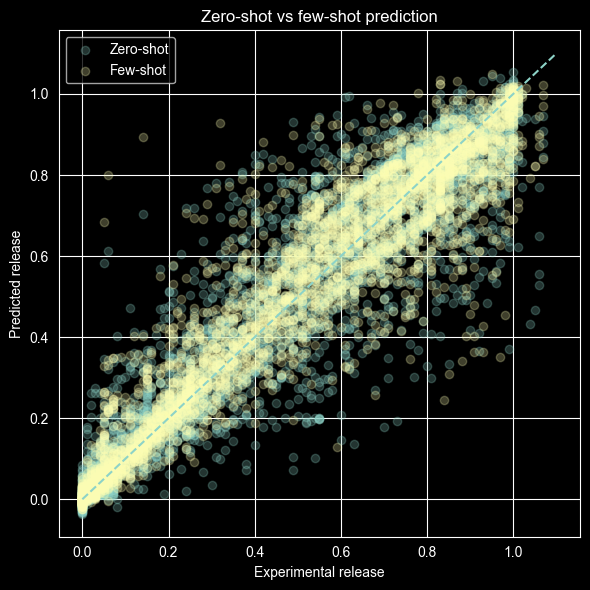

In [44]:
plt.figure(figsize=(6, 6))
plt.scatter(zero_oof["y_true"], zero_oof["y_pred"], alpha=0.25, label="Zero-shot")
plt.scatter(few_oof["y_true"], few_oof["y_pred"], alpha=0.25, label="Few-shot")
plt.plot([0, 1.1], [0, 1.1], linestyle="--")
plt.xlabel("Experimental release")
plt.ylabel("Predicted release")
plt.title("Zero-shot vs few-shot prediction")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "zero_vs_few_predicted_vs_true.png"), dpi=300)
plt.show()

### Paper comment: Zero-shot vs few-shot result

> The comparison between zero-shot and few-shot models evaluates how much information is gained from the first 24 hours of release. If the few-shot model performs better, this suggests that early burst release contains important information about the later kinetic profile. This is chemically meaningful because a strong initial burst can indicate faster diffusion, weaker drug-polymer retention, or a more porous/high-surface-area system.

## 10. Final direct model for full release profile prediction

Here we train the final LightGBM model on all rows using the few-shot features.

Important:
- Cross-validation results above are used for performance reporting.
- Training on all data here is used only for final visualization, profile simulation, SHAP, and exploratory counterfactual analysis.

In [45]:
best_direct_model = LGBMRegressor(
    n_estimators=700,
    learning_rate=0.025,
    num_leaves=31,
    min_child_samples=10,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=RANDOM_STATE,
    verbose=-1
)

best_direct_model.fit(X_few, y)

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.025
,n_estimators,700
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,10


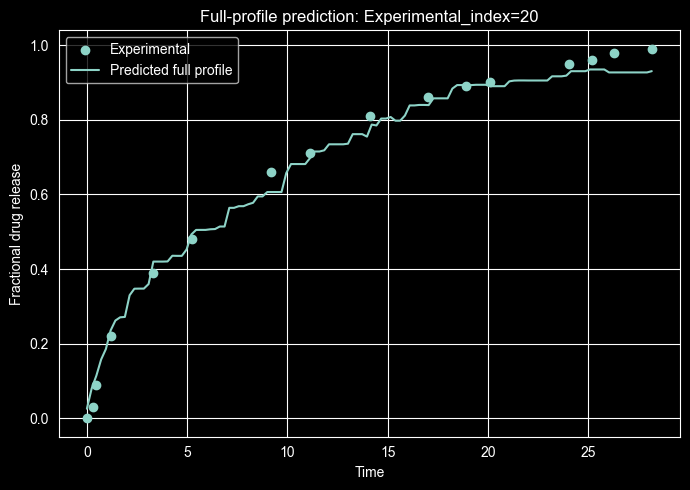

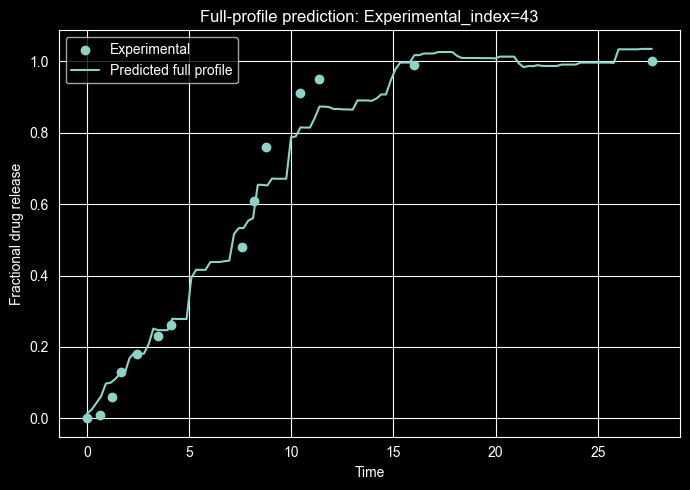

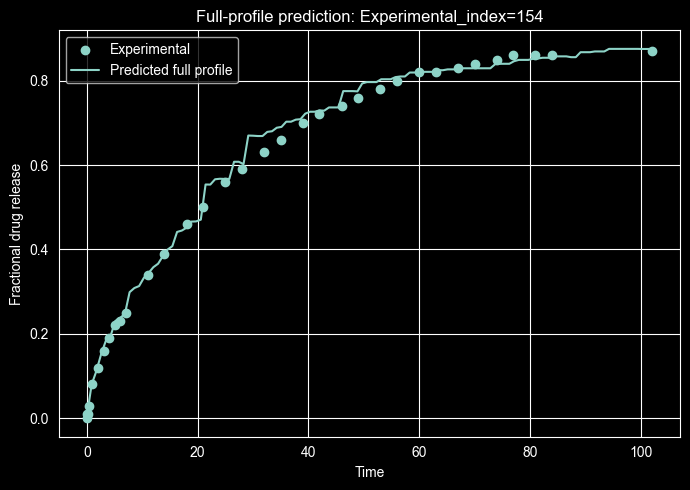

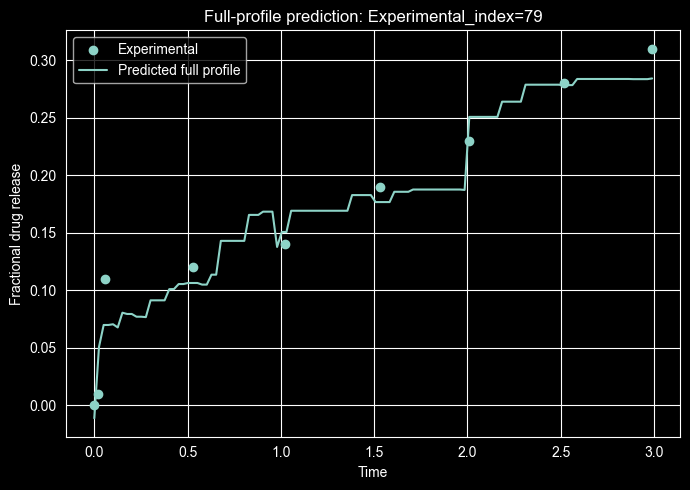

In [46]:
def predict_release_profile(model, data, profile_id, features, n_points=120, use_observed_time_range=True):
    '''
    Predicts a continuous release profile by:
    - selecting one formulation,
    - keeping formulation/drug descriptors fixed,
    - varying only Time over a grid.
    '''
    profile = data[data["Experimental_index"] == profile_id].sort_values("Time").copy()
    if profile.empty:
        raise ValueError(f"Profile ID {profile_id} not found.")

    base_row = profile.iloc[0].copy()

    if use_observed_time_range:
        t_min = profile["Time"].min()
        t_max = profile["Time"].max()
    else:
        t_min = 0
        t_max = data["Time"].max()

    time_grid = np.linspace(t_min, t_max, n_points)

    X_grid = pd.DataFrame([base_row[features].to_dict()] * n_points)
    X_grid["Time"] = time_grid

    pred = np.ravel(model.predict(X_grid[features]))

    return profile, time_grid, pred

# Choose a few example profiles for plotting.
example_profiles = df["Experimental_index"].drop_duplicates().sample(
    min(4, df["Experimental_index"].nunique()),
    random_state=RANDOM_STATE
).tolist()

for profile_id in example_profiles:
    profile, time_grid, pred = predict_release_profile(
        best_direct_model,
        df,
        profile_id,
        FEW_SHOT_FEATURES
    )

    plt.figure(figsize=(7, 5))
    plt.scatter(profile["Time"], profile["Release"], label="Experimental")
    plt.plot(time_grid, pred, label="Predicted full profile")
    plt.xlabel("Time")
    plt.ylabel("Fractional drug release")
    plt.title(f"Full-profile prediction: Experimental_index={profile_id}")
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, f"profile_prediction_{profile_id}.png"), dpi=300)
    plt.show()

### Paper comment: Full-profile prediction

> The trained model was used as a continuous release-profile predictor. For each formulation, all formulation-specific descriptors were kept constant, while `Time` was varied across a grid of values. This allowed the point-wise regression model to be used for reconstruction of full drug release curves.

## 11. SHAP explainability

SHAP is used to interpret the LightGBM model.

Recommended plots for the paper:
1. SHAP beeswarm plot = global feature importance  
2. SHAP dependence/scatter plot for `Time`  
3. SHAP dependence/scatter plot for `Polymer_MW`  
4. SHAP dependence/scatter plot for `T=1.0`  
5. Optional waterfall plot for one prediction

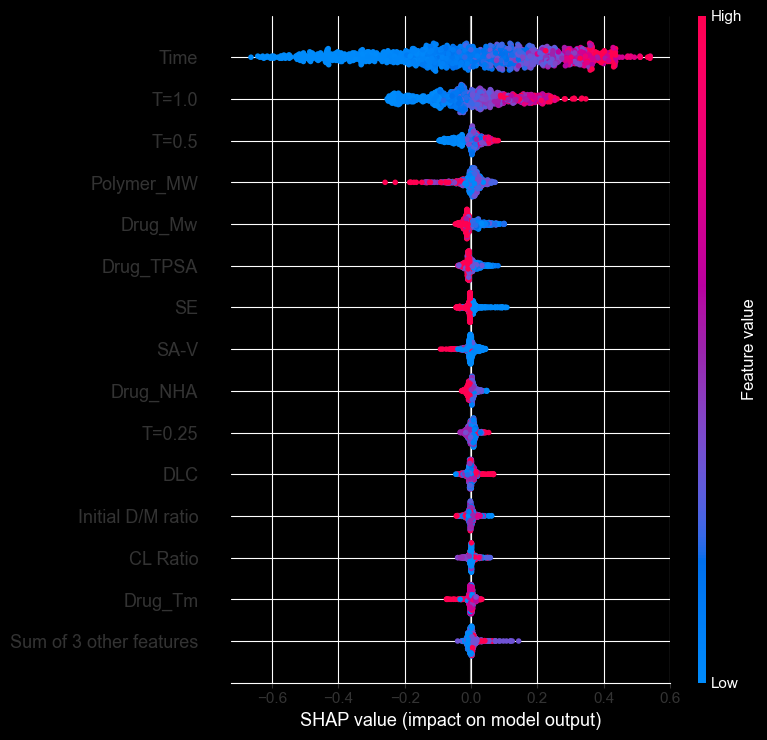

,feature,mean_abs_shap
13,Time,0.217024
16,T=1.0,0.100825
15,T=0.5,0.027200
1,Polymer_MW,0.021167
9,Drug_Mw,0.020274
10,Drug_TPSA,0.013204
8,SE,0.012561
7,SA-V,0.010179
11,Drug_NHA,0.007994
14,T=0.25,0.007866


In [47]:
import shap

# Use a sample for faster SHAP computation.
X_shap = X_few.sample(min(1200, len(X_few)), random_state=RANDOM_STATE)

explainer = shap.TreeExplainer(best_direct_model)
shap_values = explainer(X_shap)

# Beeswarm plot
shap.plots.beeswarm(shap_values, max_display=15, show=False)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "shap_beeswarm.png"), dpi=300, bbox_inches="tight")
plt.show()

# Save mean absolute SHAP importance
shap_importance = pd.DataFrame({
    "feature": X_shap.columns,
    "mean_abs_shap": np.abs(shap_values.values).mean(axis=0)
}).sort_values("mean_abs_shap", ascending=False)

display(shap_importance)
shap_importance.to_csv(os.path.join(OUTPUT_DIR, "shap_feature_importance.csv"), index=False)

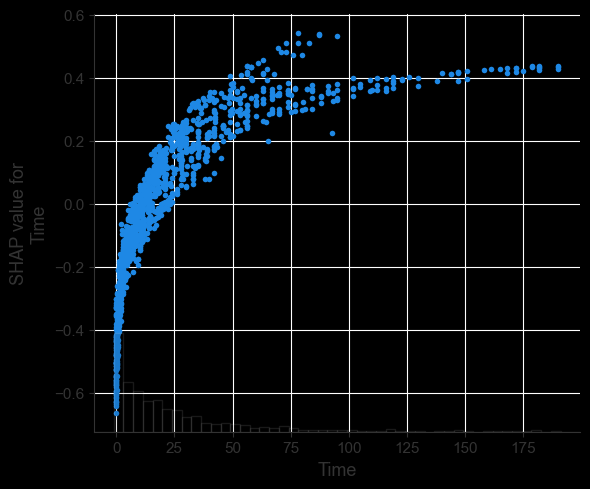

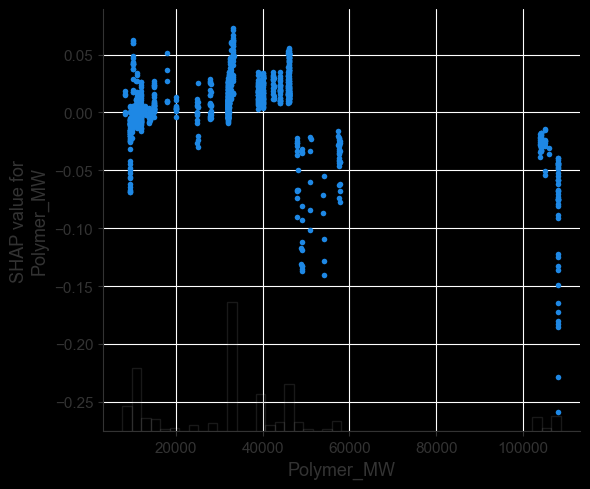

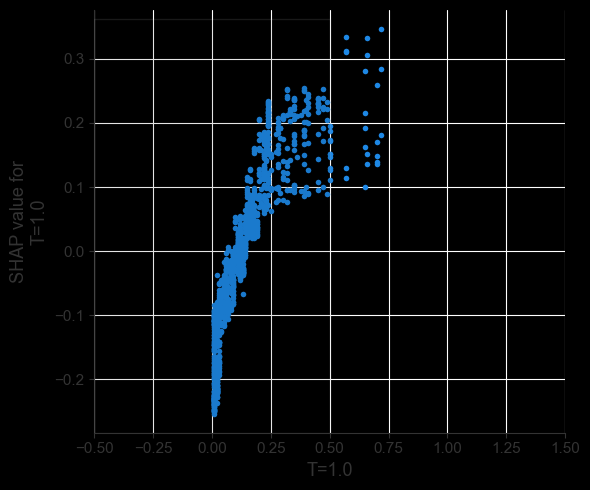

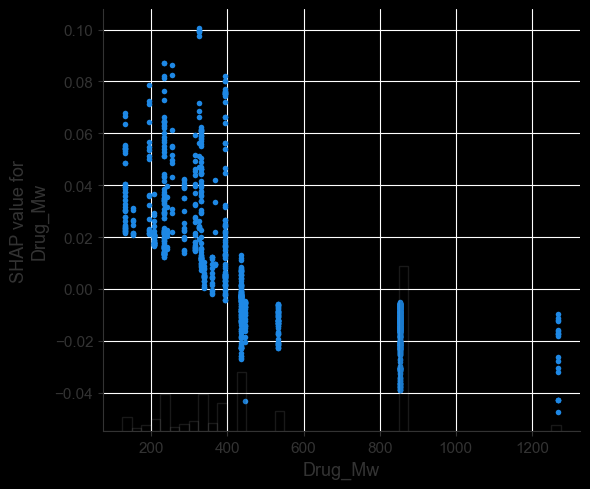

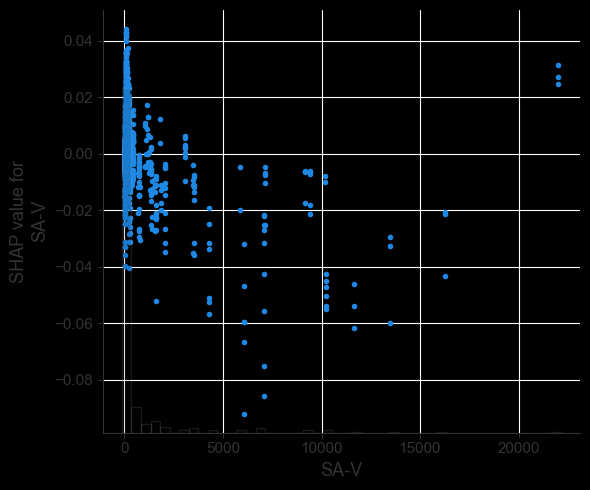

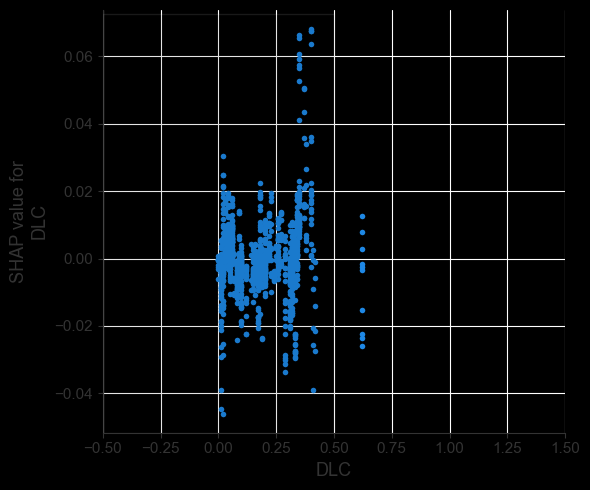

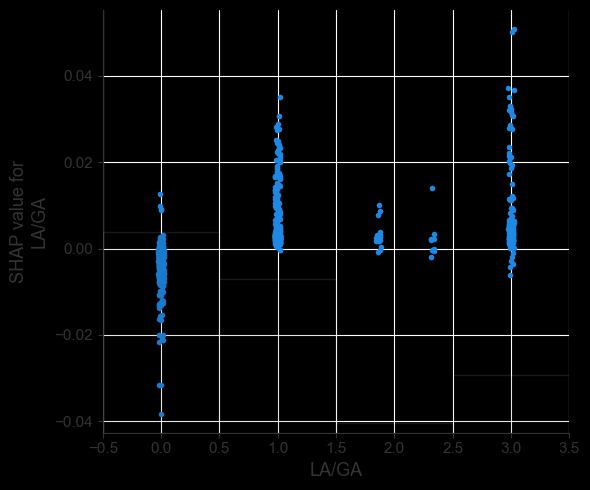

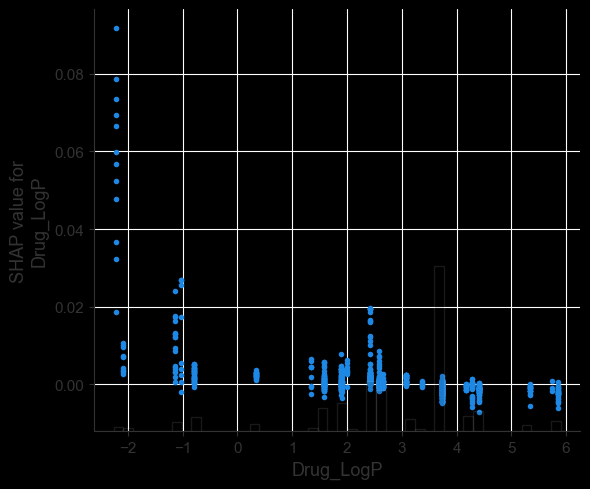

In [48]:
# Dependence/scatter plots for selected features
for feature in ["Time", "Polymer_MW", "T=1.0", "Drug_Mw", "SA-V", "DLC", "LA/GA", "Drug_LogP"]:
    if feature in X_shap.columns:
        shap.plots.scatter(shap_values[:, feature], show=False)
        plt.tight_layout()
        safe_name = feature.replace("/", "_").replace("=", "").replace(" ", "_")
        plt.savefig(os.path.join(OUTPUT_DIR, f"shap_scatter_{safe_name}.png"), dpi=300, bbox_inches="tight")
        plt.show()

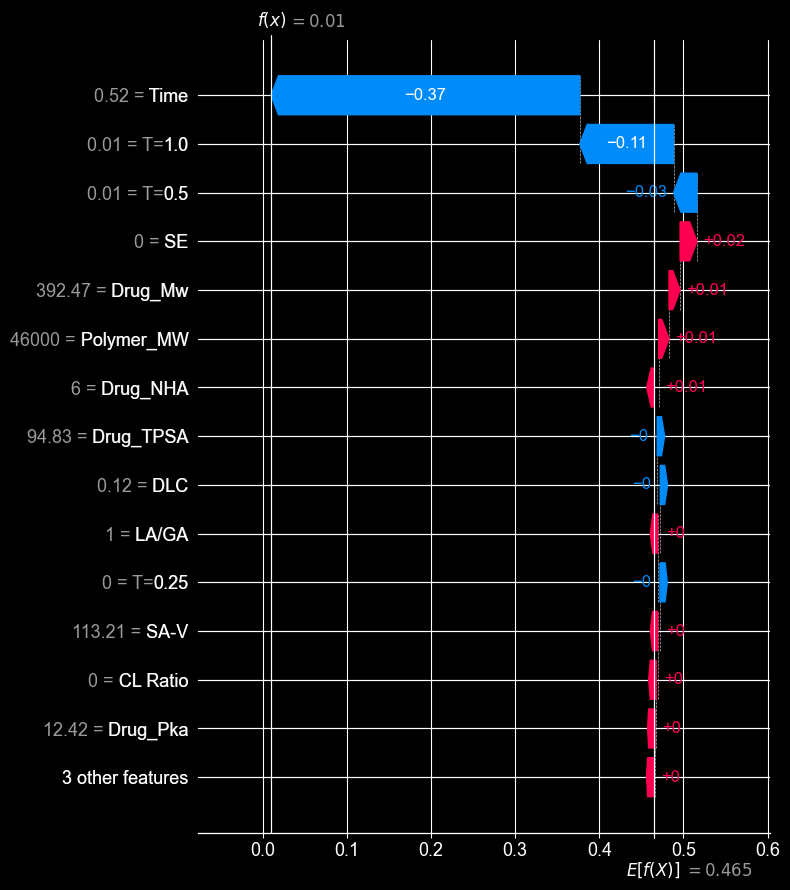

In [24]:
# Waterfall plot for one prediction
example_index = 0
shap.plots.waterfall(shap_values[example_index], max_display=15, show=False)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "shap_waterfall_example.png"), dpi=300, bbox_inches="tight")
plt.show()

### Paper comment: SHAP interpretation

> SHAP analysis was used to transform the tree-based model from a purely predictive model into an interpretable formulation model. The global SHAP ranking shows which descriptors most strongly influence predicted release, while dependence plots show whether high or low values of each descriptor increase or decrease predicted fractional release.

## 12. Hybrid kinetic ML: fit release curves first, then predict kinetic parameters

This is the more novel part.

Instead of directly predicting every time point, we first fit each experimental release profile with a kinetic equation.

Main equation used here: **Weibull model**

\[
F(t) = F_{max} \cdot \left(1 - e^{-(t/\tau)^\beta}\right)
\]

Where:
- `Fmax` = approximate plateau / maximum release
- `tau` = time-scale parameter
- `beta` = curve-shape parameter

Then ML predicts `Fmax`, `tau`, and `beta` from formulation descriptors.

> Paper comment: The hybrid model creates a grey-box workflow. The kinetic equation provides an interpretable curve structure, while ML predicts the equation parameters from formulation and drug descriptors.

In [49]:
def weibull(t, fmax, tau, beta):
    t = np.asarray(t, dtype=float)
    return fmax * (1 - np.exp(-((np.maximum(t, 0) / tau) ** beta)))

def logistic4(t, y0, fmax, k, tmid):
    t = np.asarray(t, dtype=float)
    return y0 + (fmax - y0) / (1 + np.exp(-k * (t - tmid)))

def aic_score(y_true, y_pred, n_params):
    residuals = np.asarray(y_true) - np.asarray(y_pred)
    rss = np.sum(residuals ** 2)
    n = len(y_true)
    rss = max(rss, 1e-12)
    return n * np.log(rss / n) + 2 * n_params

def fit_weibull_profile(profile):
    profile = profile.sort_values("Time")
    t = profile["Time"].values.astype(float)
    y_obs = np.clip(profile["Release"].values.astype(float), 0, 1.2)

    if len(np.unique(t)) < 4:
        return None

    t_nonzero = t[t > 0]
    tau_start = np.median(t_nonzero) if len(t_nonzero) > 0 else 1.0

    p0 = [min(1.1, max(y_obs) + 0.05), max(tau_start, 0.1), 1.0]
    bounds = ([0.0, 0.01, 0.05], [1.2, 1000.0, 10.0])

    try:
        popt, _ = curve_fit(
            weibull, t, y_obs, p0=p0, bounds=bounds, maxfev=30000
        )
        y_fit = weibull(t, *popt)
        return {
            "Fmax": popt[0],
            "tau": popt[1],
            "beta": popt[2],
            "weibull_RMSE": np.sqrt(mean_squared_error(y_obs, y_fit)),
            "weibull_AIC": aic_score(y_obs, y_fit, n_params=3)
        }
    except Exception:
        return None

def fit_logistic_profile(profile):
    profile = profile.sort_values("Time")
    t = profile["Time"].values.astype(float)
    y_obs = np.clip(profile["Release"].values.astype(float), 0, 1.2)

    if len(np.unique(t)) < 4:
        return None

    p0 = [max(0.0, min(y_obs)), min(1.1, max(y_obs) + 0.05), 0.1, np.median(t)]
    bounds = ([0.0, 0.0, 0.001, 0.0], [0.6, 1.2, 10.0, 1000.0])

    try:
        popt, _ = curve_fit(
            logistic4, t, y_obs, p0=p0, bounds=bounds, maxfev=30000
        )
        y_fit = logistic4(t, *popt)
        return {
            "log_y0": popt[0],
            "log_Fmax": popt[1],
            "log_k": popt[2],
            "log_tmid": popt[3],
            "logistic_RMSE": np.sqrt(mean_squared_error(y_obs, y_fit)),
            "logistic_AIC": aic_score(y_obs, y_fit, n_params=4)
        }
    except Exception:
        return None

In [50]:
kinetic_rows = []

for profile_id, g in df.groupby("Experimental_index"):
    weib = fit_weibull_profile(g)
    logi = fit_logistic_profile(g)

    row = {
        "Experimental_index": profile_id,
        "DP_Group": g["DP_Group"].iloc[0],
        "n_points": len(g)
    }

    if weib is not None:
        row.update(weib)

    if logi is not None:
        row.update(logi)

    kinetic_rows.append(row)

kinetic_df = pd.DataFrame(kinetic_rows)

# Decide which empirical curve fit was better for each profile, when both are available.
kinetic_df["best_curve_by_AIC"] = np.where(
    kinetic_df["weibull_AIC"] <= kinetic_df["logistic_AIC"],
    "Weibull",
    "Logistic"
)

display(kinetic_df.head())
display(kinetic_df[["weibull_RMSE", "logistic_RMSE", "best_curve_by_AIC"]].describe())
display(kinetic_df["best_curve_by_AIC"].value_counts(dropna=False))

kinetic_df.to_csv(os.path.join(OUTPUT_DIR, "kinetic_curve_fit_parameters.csv"), index=False)

,Experimental_index,DP_Group,n_points,Fmax,tau,beta,weibull_RMSE,weibull_AIC,log_y0,log_Fmax,log_k,log_tmid,logistic_RMSE,logistic_AIC,best_curve_by_AIC
0,1,DEX-PEA,29,0.568925,12.749404,0.618787,0.004433,-308.287201,2.943002e-32,0.519962,0.159328,8.973645,0.034526,-187.230082,Weibull
1,2,GEF-PLGA,18,1.200000,48.617610,0.481211,0.039125,-110.676158,5.310597e-30,0.862870,0.075771,14.349361,0.077661,-83.994639,Weibull
2,3,GEF-PLGA,8,1.030508,0.843538,1.069839,0.042068,-44.695315,5.724353e-20,0.998303,2.953395,0.646045,0.070783,-34.370273,Weibull
3,4,GEF-PLGA,19,1.072381,2.969445,0.811659,0.027058,-131.170996,7.278120e-30,1.045964,0.635324,2.285517,0.068908,-93.649471,Weibull
4,5,GEF-PLGA,17,1.200000,56.991874,1.272517,0.031936,-111.096841,2.633548e-29,1.035068,0.062559,39.488626,0.041698,-100.028491,Weibull


,weibull_RMSE,logistic_RMSE
count,181.000000,181.000000
mean,0.029172,0.049330
std,0.020676,0.021648
min,0.003651,0.003651
25%,0.016091,0.031916
50%,0.022394,0.050938
75%,0.036136,0.062440
max,0.115045,0.109968


best_curve_by_AIC
Weibull     136
Logistic     45
Name: count, dtype: int64

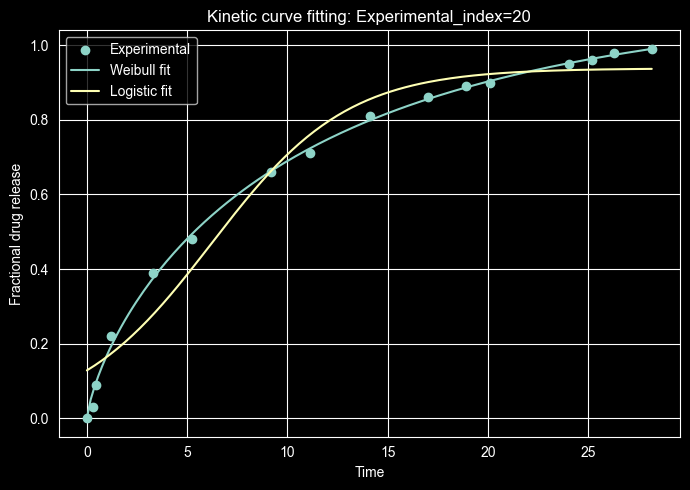

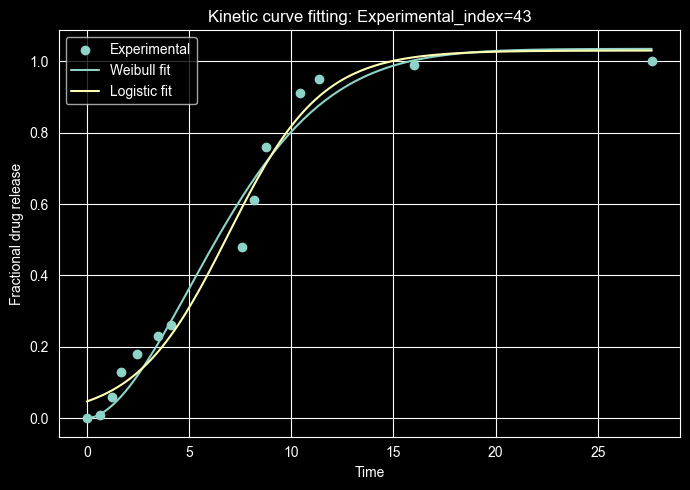

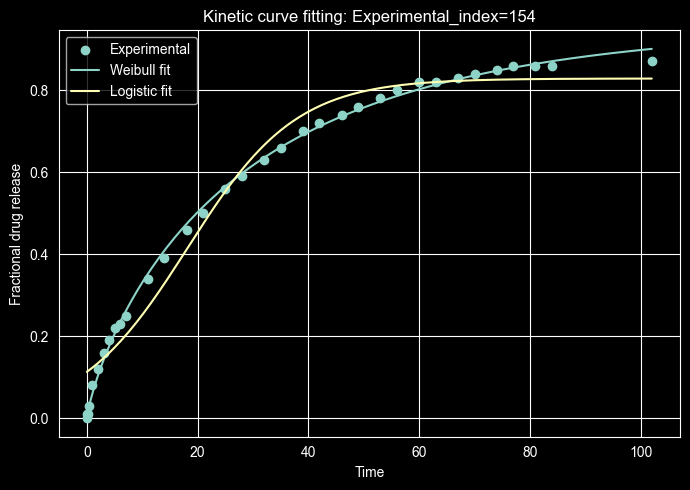

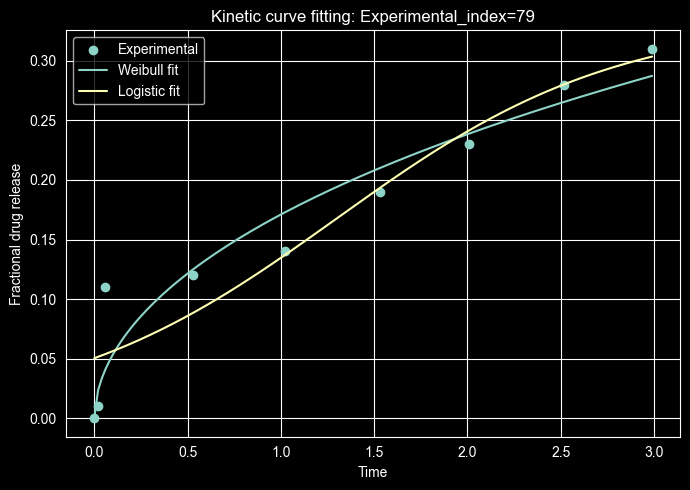

In [51]:
# Visualize fitted Weibull and Logistic curves for a few profiles.
fit_examples = kinetic_df["Experimental_index"].dropna().sample(
    min(4, len(kinetic_df)),
    random_state=RANDOM_STATE
).tolist()

for profile_id in fit_examples:
    profile = df[df["Experimental_index"] == profile_id].sort_values("Time")
    row = kinetic_df[kinetic_df["Experimental_index"] == profile_id].iloc[0]
    t_grid = np.linspace(profile["Time"].min(), profile["Time"].max(), 150)

    plt.figure(figsize=(7, 5))
    plt.scatter(profile["Time"], profile["Release"], label="Experimental")

    if not pd.isna(row.get("Fmax", np.nan)):
        y_weib = weibull(t_grid, row["Fmax"], row["tau"], row["beta"])
        plt.plot(t_grid, y_weib, label="Weibull fit")

    if not pd.isna(row.get("log_Fmax", np.nan)):
        y_log = logistic4(t_grid, row["log_y0"], row["log_Fmax"], row["log_k"], row["log_tmid"])
        plt.plot(t_grid, y_log, label="Logistic fit")

    plt.xlabel("Time")
    plt.ylabel("Fractional drug release")
    plt.title(f"Kinetic curve fitting: Experimental_index={profile_id}")
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, f"kinetic_fit_{profile_id}.png"), dpi=300)
    plt.show()

### Paper comment: Kinetic curve fitting

> Each experimental release profile was fitted with empirical kinetic equations. The Weibull model was used as the main curve representation because it can describe different release shapes using only three parameters. Logistic fitting was included as a comparison for sigmoidal profiles. The fitted parameters summarize the entire release curve into interpretable kinetic descriptors.

## 13. Train ML to predict Weibull kinetic parameters

Now we predict:
- `Fmax`
- `tau`
- `beta`

from formulation descriptors.

This reconstructs a full release curve without directly predicting every time point.

In [28]:
# One row per profile with formulation descriptors.
# We take the first row because formulation descriptors are constant within a profile.
profile_features_df = (
    df.groupby("Experimental_index")
      .first()
      .reset_index()
)

# Features for kinetic parameter prediction.
# Remove Time because the kinetic parameters already describe the whole time profile.
FORMULATION_FEATURES_FEW = [c for c in FEW_SHOT_FEATURES if c != "Time"]
FORMULATION_FEATURES_ZERO = [c for c in ZERO_SHOT_FEATURES if c != "Time"]

profile_param_df = kinetic_df.merge(
    profile_features_df[["Experimental_index", "DP_Group"] + FORMULATION_FEATURES_FEW],
    on=["Experimental_index", "DP_Group"],
    how="left"
)

# Keep only profiles with successful Weibull fit.
profile_param_df = profile_param_df.dropna(subset=["Fmax", "tau", "beta"]).reset_index(drop=True)

display(profile_param_df.head())
print("Number of profiles with successful Weibull fit:", len(profile_param_df))

,Experimental_index,DP_Group,n_points,Fmax,tau,beta,weibull_RMSE,weibull_AIC,log_y0,log_Fmax,log_k,log_tmid,logistic_RMSE,logistic_AIC,best_curve_by_AIC,LA/GA,Polymer_MW,CL Ratio,Drug_Tm,Drug_Pka,Initial D/M ratio,DLC,SA-V,SE,Drug_Mw,Drug_TPSA,Drug_NHA,Drug_LogP,T=0.25,T=0.5,T=1.0
0,1,DEX-PEA,29,0.568925,12.749404,0.618787,0.004433,-308.287201,2.943002e-32,0.519962,0.159328,8.973645,0.034526,-187.230082,Weibull,0.0,49000.0,0.0,262.0,12.42,0.2,0.15,422.54,0.0,392.47,94.83,6.0,1.90,0.04,0.05,0.09
1,2,GEF-PLGA,18,1.200000,48.617610,0.481211,0.039125,-110.676158,5.310597e-30,0.862870,0.075771,14.349361,0.077661,-83.994639,Weibull,1.0,44000.0,0.0,213.0,16.11,0.1,0.07,101.69,1.0,446.91,68.74,9.0,4.28,0.05,0.10,0.19
2,3,GEF-PLGA,8,1.030508,0.843538,1.069839,0.042068,-44.695315,5.724353e-20,0.998303,2.953395,0.646045,0.070783,-34.370273,Weibull,1.0,44000.0,0.0,213.0,16.11,0.1,0.03,1200.00,1.0,446.91,68.74,9.0,4.28,0.25,0.45,0.72
3,4,GEF-PLGA,19,1.072381,2.969445,0.811659,0.027058,-131.170996,7.278120e-30,1.045964,0.635324,2.285517,0.068908,-93.649471,Weibull,1.0,44000.0,0.0,213.0,16.11,0.1,0.06,187.50,1.0,446.91,68.74,9.0,4.28,0.11,0.22,0.39
4,5,GEF-PLGA,17,1.200000,56.991874,1.272517,0.031936,-111.096841,2.633548e-29,1.035068,0.062559,39.488626,0.041698,-100.028491,Weibull,1.0,44000.0,0.0,213.0,16.11,0.1,0.08,85.71,1.0,446.91,68.74,9.0,4.28,0.02,0.02,0.03


Number of profiles with successful Weibull fit: 181


In [29]:
def evaluate_parameter_model_cv(profile_df, features, targets, group_col="DP_Group", n_splits=5):
    '''
    Evaluates ML prediction of kinetic parameters at profile level.
    '''
    Xp = profile_df[features]
    Yp = profile_df[targets]

    # If there are enough groups, use GroupKFold by DP_Group.
    n_groups = profile_df[group_col].nunique()
    if n_groups >= n_splits:
        splitter = GroupKFold(n_splits=n_splits)
        split_iter = splitter.split(Xp, Yp, profile_df[group_col])
    else:
        splitter = KFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
        split_iter = splitter.split(Xp, Yp)

    pred = np.zeros_like(Yp.values, dtype=float)

    base_model = MultiOutputRegressor(
        LGBMRegressor(
            n_estimators=400,
            learning_rate=0.03,
            num_leaves=15,
            min_child_samples=5,
            random_state=RANDOM_STATE,
            verbose=-1
        )
    )

    for fold, (train_idx, test_idx) in enumerate(split_iter):
        model = clone(base_model)
        model.fit(Xp.iloc[train_idx], Yp.iloc[train_idx])
        pred[test_idx, :] = model.predict(Xp.iloc[test_idx])

    rows = []
    for i, target in enumerate(targets):
        rows.append({
            "target": target,
            "MAE": mean_absolute_error(Yp.iloc[:, i], pred[:, i]),
            "RMSE": np.sqrt(mean_squared_error(Yp.iloc[:, i], pred[:, i])),
            "R2": r2_score(Yp.iloc[:, i], pred[:, i])
        })

    pred_df = profile_df[["Experimental_index", "DP_Group"]].copy()
    for i, target in enumerate(targets):
        pred_df[f"{target}_true"] = Yp.iloc[:, i].values
        pred_df[f"{target}_pred"] = pred[:, i]

    return pd.DataFrame(rows), pred_df

PARAM_TARGETS = ["Fmax", "tau", "beta"]

param_results, param_pred_df = evaluate_parameter_model_cv(
    profile_param_df,
    FORMULATION_FEATURES_FEW,
    PARAM_TARGETS,
    group_col="DP_Group",
    n_splits=5
)

display(param_results)
display(param_pred_df.head())

param_results.to_csv(os.path.join(OUTPUT_DIR, "weibull_parameter_prediction_results.csv"), index=False)
param_pred_df.to_csv(os.path.join(OUTPUT_DIR, "weibull_parameter_oof_predictions.csv"), index=False)

,target,MAE,RMSE,R2
0,Fmax,0.185274,0.238321,-0.345484
1,tau,64.324424,119.061948,-1.073256
2,beta,0.539448,0.809326,0.704539


,Experimental_index,DP_Group,Fmax_true,Fmax_pred,tau_true,tau_pred,beta_true,beta_pred
0,1,DEX-PEA,0.568925,1.140198,12.749404,96.651214,0.618787,0.765650
1,2,GEF-PLGA,1.200000,1.108145,48.617610,11.382586,0.481211,1.073516
2,3,GEF-PLGA,1.030508,1.048675,0.843538,5.742736,1.069839,0.969579
3,4,GEF-PLGA,1.072381,1.089227,2.969445,6.505777,0.811659,0.943490
4,5,GEF-PLGA,1.200000,0.989548,56.991874,30.967176,1.272517,1.736965


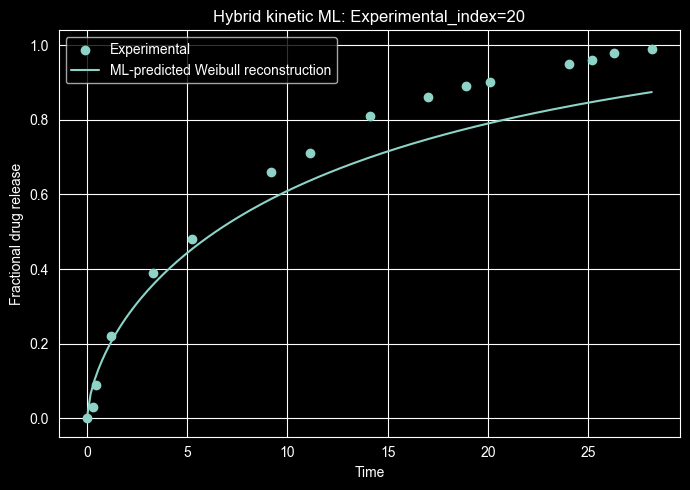

Profile: 20 {'Fmax_pred': np.float64(1.10580030948501), 'tau_pred': np.float64(14.10125381709806), 'beta_pred': np.float64(0.6458111529269468)}


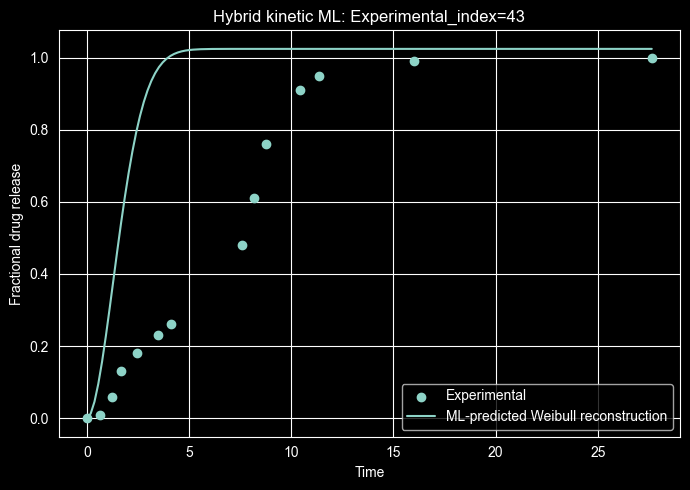

Profile: 43 {'Fmax_pred': np.float64(1.0238955989502465), 'tau_pred': np.float64(1.9492244220609625), 'beta_pred': np.float64(1.8586220053753222)}


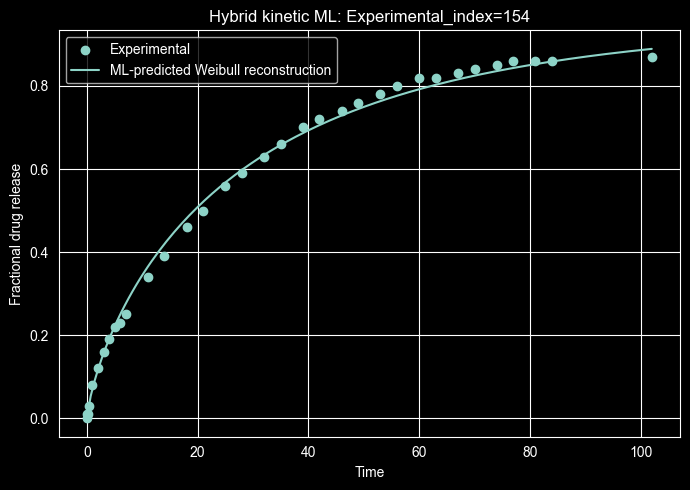

Profile: 154 {'Fmax_pred': np.float64(0.9586968161696282), 'tau_pred': np.float64(28.8516217518485), 'beta_pred': np.float64(0.7638660627029062)}


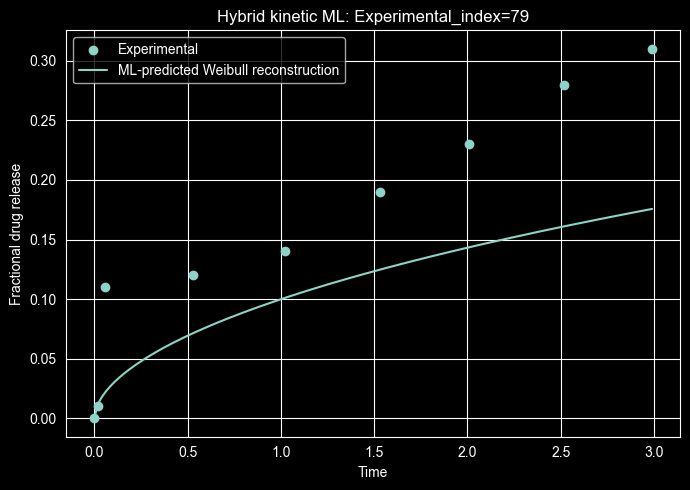

Profile: 79 {'Fmax_pred': np.float64(1.1569904894124152), 'tau_pred': np.float64(79.99148479684274), 'beta_pred': np.float64(0.5487925947672662)}


In [30]:
# Train final parameter model on all profiles for reconstruction examples.
final_param_model = MultiOutputRegressor(
    LGBMRegressor(
        n_estimators=400,
        learning_rate=0.03,
        num_leaves=15,
        min_child_samples=5,
        random_state=RANDOM_STATE,
        verbose=-1
    )
)

final_param_model.fit(
    profile_param_df[FORMULATION_FEATURES_FEW],
    profile_param_df[PARAM_TARGETS]
)

def reconstruct_weibull_curve_from_ml(param_model, profile_param_df, profile_id, t_grid):
    row = profile_param_df[profile_param_df["Experimental_index"] == profile_id].iloc[0]
    X_one = pd.DataFrame([row[FORMULATION_FEATURES_FEW].to_dict()])
    fmax, tau, beta = param_model.predict(X_one)[0]
    y_curve = weibull(t_grid, fmax, tau, beta)
    return y_curve, {"Fmax_pred": fmax, "tau_pred": tau, "beta_pred": beta}

# Plot reconstructed hybrid curves.
hybrid_examples = profile_param_df["Experimental_index"].sample(
    min(4, len(profile_param_df)),
    random_state=RANDOM_STATE
).tolist()

for profile_id in hybrid_examples:
    profile = df[df["Experimental_index"] == profile_id].sort_values("Time")
    t_grid = np.linspace(profile["Time"].min(), profile["Time"].max(), 150)

    y_hybrid, pred_params = reconstruct_weibull_curve_from_ml(
        final_param_model,
        profile_param_df,
        profile_id,
        t_grid
    )

    plt.figure(figsize=(7, 5))
    plt.scatter(profile["Time"], profile["Release"], label="Experimental")
    plt.plot(t_grid, y_hybrid, label="ML-predicted Weibull reconstruction")
    plt.xlabel("Time")
    plt.ylabel("Fractional drug release")
    plt.title(f"Hybrid kinetic ML: Experimental_index={profile_id}")
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, f"hybrid_weibull_reconstruction_{profile_id}.png"), dpi=300)
    plt.show()

    print("Profile:", profile_id, pred_params)

### Paper comment: Hybrid kinetic ML

> The hybrid kinetic ML model reduced each release curve to kinetic parameters and then learned the relationship between formulation descriptors and these parameters. This approach is more interpretable than direct point-wise prediction because parameters such as `Fmax`, `tau`, and `beta` correspond to plateau behavior, release time scale, and curve shape.

## 14. Optional: Evaluate hybrid curve prediction on held-out profiles

This cell predicts Weibull parameters in cross-validation, reconstructs the release values at the original experimental time points, and evaluates the reconstructed curves.

This gives a fairer estimate of the hybrid model.

In [31]:
def hybrid_weibull_group_cv(profile_df, raw_df, features, targets, group_col="DP_Group", n_splits=5):
    '''
    Cross-validated hybrid model:
    1. Split profiles.
    2. Train ML to predict Weibull parameters.
    3. Predict parameters for held-out profiles.
    4. Reconstruct release at the original experimental time points.
    '''
    Xp = profile_df[features]
    Yp = profile_df[targets]

    n_groups = profile_df[group_col].nunique()
    if n_groups >= n_splits:
        splitter = GroupKFold(n_splits=n_splits)
        split_iter = splitter.split(Xp, Yp, profile_df[group_col])
    else:
        splitter = KFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
        split_iter = splitter.split(Xp, Yp)

    all_pred_rows = []

    base_model = MultiOutputRegressor(
        LGBMRegressor(
            n_estimators=400,
            learning_rate=0.03,
            num_leaves=15,
            min_child_samples=5,
            random_state=RANDOM_STATE,
            verbose=-1
        )
    )

    for fold, (train_idx, test_idx) in enumerate(split_iter):
        model = clone(base_model)
        train_profiles = profile_df.iloc[train_idx]
        test_profiles = profile_df.iloc[test_idx]

        model.fit(train_profiles[features], train_profiles[targets])

        param_preds = model.predict(test_profiles[features])

        for row_i, (_, profile_row) in enumerate(test_profiles.iterrows()):
            profile_id = profile_row["Experimental_index"]
            fmax, tau, beta = param_preds[row_i]

            raw_profile = raw_df[raw_df["Experimental_index"] == profile_id].copy()
            y_pred = weibull(raw_profile["Time"].values, fmax, tau, beta)

            temp = pd.DataFrame({
                "Experimental_index": profile_id,
                "DP_Group": raw_profile["DP_Group"].values,
                "Time": raw_profile["Time"].values,
                "y_true": raw_profile["Release"].values,
                "y_pred_hybrid": y_pred,
                "fold": fold
            })
            all_pred_rows.append(temp)

    pred_df = pd.concat(all_pred_rows, ignore_index=True)
    metrics = regression_metrics(pred_df["y_true"], pred_df["y_pred_hybrid"])
    return metrics, pred_df

hybrid_metrics, hybrid_pred_df = hybrid_weibull_group_cv(
    profile_param_df,
    df,
    FORMULATION_FEATURES_FEW,
    PARAM_TARGETS,
    group_col="DP_Group",
    n_splits=5
)

display(pd.DataFrame([hybrid_metrics]))
display(hybrid_pred_df.head())

hybrid_pred_df.to_csv(os.path.join(OUTPUT_DIR, "hybrid_weibull_oof_curve_predictions.csv"), index=False)
pd.DataFrame([hybrid_metrics]).to_csv(os.path.join(OUTPUT_DIR, "hybrid_weibull_oof_metrics.csv"), index=False)

ValueError: Input contains NaN.

In [ ]:
plt.figure(figsize=(6, 6))
plt.scatter(hybrid_pred_df["y_true"], hybrid_pred_df["y_pred_hybrid"], alpha=0.3)
plt.plot([0, 1.1], [0, 1.1], linestyle="--")
plt.xlabel("Experimental release")
plt.ylabel("Hybrid Weibull predicted release")
plt.title("Hybrid kinetic ML: predicted vs experimental release")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "hybrid_weibull_predicted_vs_true.png"), dpi=300)
plt.show()

### Paper comment: Direct vs hybrid model

> The direct model is expected to achieve stronger point-wise accuracy because it predicts each release observation directly. The hybrid model may be less flexible, but it provides a compact kinetic description of the entire release profile and produces smoother, more physically interpretable curves.

## 15. Monotonic correction and physically plausible predictions

Cumulative release should usually:
- stay approximately between 0 and 1,
- not decrease over time,
- approach a plateau.

Tree models can sometimes produce small unrealistic decreases.  
A simple correction is to clip values and apply cumulative maximum.

In [ ]:
def monotonic_correct(pred, lower=0.0, upper=1.05):
    pred = np.asarray(pred, dtype=float)
    pred = np.clip(pred, lower, upper)
    pred = np.maximum.accumulate(pred)
    return pred

# Example: raw vs corrected prediction
profile_id = example_profiles[0]
profile, time_grid, pred_raw = predict_release_profile(
    best_direct_model,
    df,
    profile_id,
    FEW_SHOT_FEATURES
)

pred_corrected = monotonic_correct(pred_raw)

plt.figure(figsize=(7, 5))
plt.scatter(profile["Time"], profile["Release"], label="Experimental")
plt.plot(time_grid, pred_raw, label="Raw ML prediction", alpha=0.7)
plt.plot(time_grid, pred_corrected, label="Monotonic corrected prediction")
plt.xlabel("Time")
plt.ylabel("Fractional drug release")
plt.title(f"Monotonic correction: Experimental_index={profile_id}")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f"monotonic_correction_{profile_id}.png"), dpi=300)
plt.show()

### Optional: LightGBM monotonic constraint on `Time`

This forces the model to learn a non-decreasing relationship with `Time`.

Use it as an additional experiment, not necessarily as your main model.

In [ ]:
monotone_constraints = [
    1 if feature == "Time" else 0
    for feature in FEW_SHOT_FEATURES
]

monotonic_lgbm = LGBMRegressor(
    n_estimators=700,
    learning_rate=0.025,
    num_leaves=31,
    min_child_samples=10,
    subsample=0.9,
    colsample_bytree=0.9,
    monotone_constraints=monotone_constraints,
    random_state=RANDOM_STATE,
    verbose=-1
)

mono_fold_df, mono_summary, mono_oof = evaluate_group_cv(
    monotonic_lgbm,
    X_few,
    y,
    groups,
    n_splits=5
)

display(pd.DataFrame([
    {"model": "LightGBM raw few-shot", **few_summary},
    {"model": "LightGBM monotonic on Time", **mono_summary}
]))

### Paper comment: Monotonic correction

> Since cumulative release should generally increase over time, predictions were additionally checked for physical plausibility. A simple monotonic post-processing step was applied by clipping predictions to a valid release interval and enforcing non-decreasing release over time. A monotonic LightGBM model was also tested by constraining the `Time` feature to have a positive effect.

## 16. Simple uncertainty interval from cross-validation residuals

This is not a full Bayesian uncertainty model, but it is simple and useful.

We use cross-validated residuals from the few-shot LightGBM model:
- calculate absolute errors,
- take the 90th percentile,
- use it as an approximate prediction interval width.

In [ ]:
# Absolute residuals from the few-shot OOF predictions
few_oof["abs_error"] = np.abs(few_oof["y_true"] - few_oof["y_pred"])

q80 = np.quantile(few_oof["abs_error"], 0.80)
q90 = np.quantile(few_oof["abs_error"], 0.90)
q95 = np.quantile(few_oof["abs_error"], 0.95)

print("Approximate residual interval widths:")
print("80%:", q80)
print("90%:", q90)
print("95%:", q95)

# Plot one profile with approximate interval.
profile_id = example_profiles[0]
profile, time_grid, pred = predict_release_profile(
    best_direct_model,
    df,
    profile_id,
    FEW_SHOT_FEATURES
)

pred_corr = monotonic_correct(pred)
lower = np.clip(pred_corr - q90, 0, 1.05)
upper = np.clip(pred_corr + q90, 0, 1.05)

plt.figure(figsize=(7, 5))
plt.scatter(profile["Time"], profile["Release"], label="Experimental")
plt.plot(time_grid, pred_corr, label="Prediction")
plt.fill_between(time_grid, lower, upper, alpha=0.2, label="Approx. 90% interval")
plt.xlabel("Time")
plt.ylabel("Fractional drug release")
plt.title(f"Prediction interval: Experimental_index={profile_id}")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f"prediction_interval_{profile_id}.png"), dpi=300)
plt.show()

### Paper comment: Uncertainty

> Approximate uncertainty intervals were added using cross-validated residuals. Although this is a simple empirical uncertainty estimate, it is useful for formulation development because it shows where predictions should be interpreted cautiously and where additional experiments may be needed.

## 17. Chemistry interpretation helper

Use the SHAP ranking and chemistry knowledge together.

This table gives short comments you can adapt in the discussion section.

In [ ]:
chemistry_comments = pd.DataFrame([
    {
        "Feature": "Time",
        "Interpretation": "Release should generally increase with time. High SHAP importance confirms that the model learned the kinetic nature of the dataset."
    },
    {
        "Feature": "T=1.0",
        "Interpretation": "Early 24h release acts as a proxy for initial burst release. High values usually indicate faster release behavior."
    },
    {
        "Feature": "Polymer_MW",
        "Interpretation": "Higher polymer molecular weight can slow water ingress, hydrolysis, polymer erosion, and drug diffusion, often reducing release rate."
    },
    {
        "Feature": "SA-V",
        "Interpretation": "Surface-area-to-volume ratio is linked to particle geometry. Higher SA-V can shorten diffusion distance and increase exposure to release medium."
    },
    {
        "Feature": "DLC",
        "Interpretation": "Drug loading capacity can affect concentration gradient, pore formation, burst release, and drug distribution inside the polymer matrix."
    },
    {
        "Feature": "LA/GA",
        "Interpretation": "The lactide/glycolide ratio affects PLGA hydrophobicity and degradation rate. This should be interpreted carefully because the dataset encodes non-PLGA systems with simplified values."
    },
    {
        "Feature": "Drug_Mw",
        "Interpretation": "Larger molecules may diffuse more slowly through the polymer matrix and can show stronger dependence on polymer morphology."
    },
    {
        "Feature": "Drug_LogP",
        "Interpretation": "Lipophilicity affects drug-polymer affinity and partitioning into the aqueous release medium. More lipophilic drugs may be retained longer in hydrophobic matrices."
    },
    {
        "Feature": "Drug_Pka",
        "Interpretation": "Ionization affects solubility, interaction with polymer end groups, and release into the medium."
    }
])

display(chemistry_comments)
chemistry_comments.to_csv(os.path.join(OUTPUT_DIR, "chemistry_interpretation_comments.csv"), index=False)

### Paper paragraph: Mechanistic interpretation

You can adapt this:

> The model did not only learn that release increases with time. SHAP analysis showed that early release, polymer molecular weight, particle geometry, drug loading, and drug physicochemical descriptors contributed to the predicted release profile. This is chemically reasonable. The early 24 h release value reflects burst release and therefore provides information about the later kinetic profile. Polymer molecular weight is linked to degradation rate and diffusional resistance, while SA-V describes the geometric exposure of the formulation to the release medium. Drug molecular weight and LogP describe how easily the molecule can diffuse through or partition out of the polymer matrix. Therefore, the model interpretation is consistent with known formulation mechanisms rather than being only a statistical black box.

## 18. Counterfactual sensitivity analysis

This is optional but useful for the discussion.

For one selected profile, we change one feature at a time and predict how the release curve changes.

Important wording:
- Do **not** say this proves causality.
- Say it is **model-based counterfactual sensitivity analysis**.

In [ ]:
def counterfactual_profile_plot(model, data, profile_id, features, feature_to_change, values, n_points=120):
    profile = data[data["Experimental_index"] == profile_id].sort_values("Time").copy()
    base_row = profile.iloc[0].copy()
    time_grid = np.linspace(profile["Time"].min(), profile["Time"].max(), n_points)

    plt.figure(figsize=(7, 5))
    plt.scatter(profile["Time"], profile["Release"], label="Experimental", alpha=0.8)

    for value in values:
        X_grid = pd.DataFrame([base_row[features].to_dict()] * n_points)
        X_grid["Time"] = time_grid
        X_grid[feature_to_change] = value

        pred = model.predict(X_grid[features])
        pred = monotonic_correct(pred)

        plt.plot(time_grid, pred, label=f"{feature_to_change}={value:.3g}")

    plt.xlabel("Time")
    plt.ylabel("Fractional drug release")
    plt.title(f"Counterfactual sensitivity: {feature_to_change}, profile={profile_id}")
    plt.legend()
    plt.tight_layout()
    safe_name = feature_to_change.replace("/", "_").replace("=", "").replace(" ", "_")
    plt.savefig(os.path.join(OUTPUT_DIR, f"counterfactual_{safe_name}_{profile_id}.png"), dpi=300)
    plt.show()

profile_id = example_profiles[0]

# Choose realistic values from quantiles in the dataset.
for feature_to_change in ["Polymer_MW", "SA-V", "DLC", "Drug_LogP"]:
    if feature_to_change in FEW_SHOT_FEATURES:
        values = df[feature_to_change].quantile([0.25, 0.50, 0.75]).values
        counterfactual_profile_plot(
            best_direct_model,
            df,
            profile_id,
            FEW_SHOT_FEATURES,
            feature_to_change,
            values
        )

### Paper comment: Counterfactual analysis

> A model-based counterfactual sensitivity analysis was performed by fixing one formulation profile and changing selected descriptors one at a time. This does not prove causality, but it provides a useful way to visualize how the trained model expects changes in polymer molecular weight, surface-area-to-volume ratio, drug loading, or lipophilicity to affect the predicted release profile.

## 19. Suggested final paper structure

Use this exact structure if you want the project to be clear:

1. **Introduction**  
   LAI systems, why release prediction is hard, why ML is useful.

2. **Dataset and preliminary Orange baseline**  
   Mention your homework: EDA, correlation/VIF, RReliefF, and model comparison.

3. **Python reproducible workflow**  
   Data loading, preprocessing, and grouped validation.

4. **Baseline model comparison**  
   Ridge/PLS vs Random Forest/Gradient Boosting/XGBoost/LightGBM.

5. **Zero-shot vs few-shot prediction**  
   Main comparison: no early release vs early release included.

6. **Full release profile prediction**  
   Fix formulation descriptors and vary only `Time`.

7. **SHAP explainability**  
   Interpret important features chemically.

8. **Hybrid kinetic ML**  
   Fit Weibull/logistic curves, predict kinetic parameters, reconstruct full profiles.

9. **Physical plausibility and uncertainty**  
   Monotonic correction, monotonic LightGBM, residual-based intervals.

10. **Mechanistic discussion**  
   Polymer_MW, SA-V, DLC, LA/GA, Drug_Mw, Drug_LogP, early burst.

11. **Conclusion**  
   Tree-based ML is strong for prediction, few-shot improves performance, SHAP and kinetic modeling make the model more interpretable.

## 20. Exported files

All figures and tables are saved in the folder:

`lai_outputs/`

You can download them from Colab and use them in the paper.

In [ ]:
print("Saved output files:")
for file in sorted(os.listdir(OUTPUT_DIR)):
    print(file)